# Project - WiFi localization using RSSI signals

## Exploratory Data Analysis

Loading dataset

In [79]:
import kagglehub # Make sure to install kagglehub using -pip install kagglehub
# Download latest version
path = kagglehub.dataset_download("brosnanyuen/wifi-rssi-indoor-localization")

In [80]:
import pandas as pd

# Load the raw dataset
raw_dataset = path + "/SRL_KNN_RNN_Code_Folder/SSP/UpdatedDatabase_8June2018_11MAC.csv"
df = pd.read_csv(raw_dataset, header=1)
print(df.head()) 
print(df.shape)

     X    Y  84:16:f9:9f:41:d4  b0:c7:45:b3:d0:b8  84:16:f9:9f:40:15  \
0  1.0 -0.5                -38                -50                -46   
1  1.0 -0.5                -32                -48                -46   
2  1.0 -0.5                -33                -56                -49   
3  1.0 -0.5                -32                -51                -51   
4  1.0 -0.5                -33                -49                -47   

   84:16:f9:9f:41:d3  84:16:f9:9f:53:c5  84:16:f9:9f:40:14  84:16:f9:9f:55:ed  \
0                -49                -70                -58                -66   
1                -47                -70                -60                -61   
2                -46                -74                -62                -58   
3                -46                -74                -58                -60   
4                -45                -74                -57                -60   

   b0:c7:45:b3:d0:bc  00:19:5b:06:bf:c2  84:16:f9:9f:53:c4  84:16:f9:9f:55:ec  


Looking at the data, we see two columns labeled X,Y which corresponds to a 2D spatial coordinate. This will be our target variables if we make a regression model. The rest of the columns show 11 RSSI features corresponding to 11 router accesspoints MAC adresses. These 11 features indicate the RSSI signal strength at a given X,Y coordinate. 

### Visuaualizing signal strength on X,Y data points

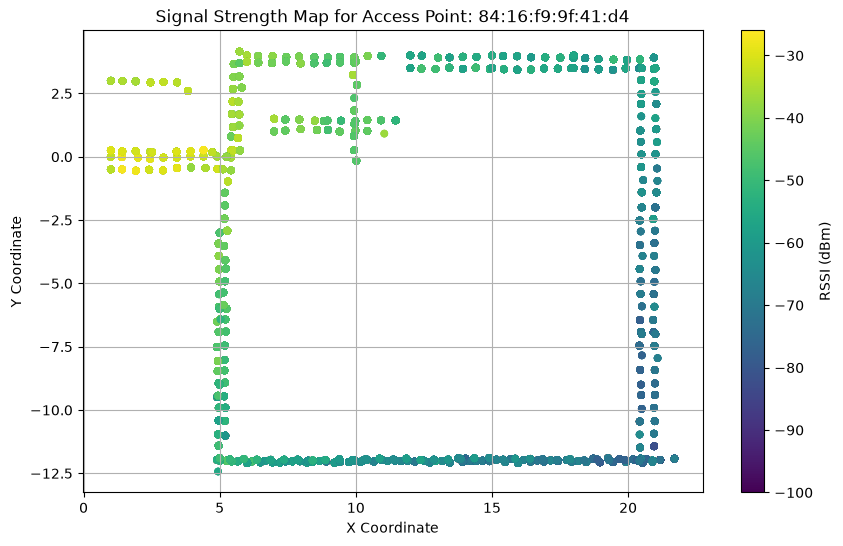

In [81]:
import matplotlib.pyplot as plt


ap_mac = df.columns[2]  # First access point

plt.figure(figsize=(10, 6))
sc = plt.scatter(df['X'], df['Y'], c=df[ap_mac], cmap='viridis', s=20)
plt.colorbar(sc, label='RSSI (dBm)')
plt.title(f"Signal Strength Map for Access Point: {ap_mac}")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.show()

This scatterplot visualizes the physical layout of the building. The first access point is located at the entrance of the floor which will act as the starting refrence of the coordinate space. The samples were taken continously and periodically from a robot on wheels using simple straight paths along the office floor. 

Signal strength is measured decibel milliwat (dBm). The closer a datapoint is to 0 dBm, the stronger the signal will be. The reason why it is measured in the dB scale is because the WiFi signals drop exponentially the further away you are, leading to very small decimal numbers which is inneficient for machine learning algorithms. Scaling the data logarithmically helps vizualize the data better and easier to compare. 

### Investigating RSSI further

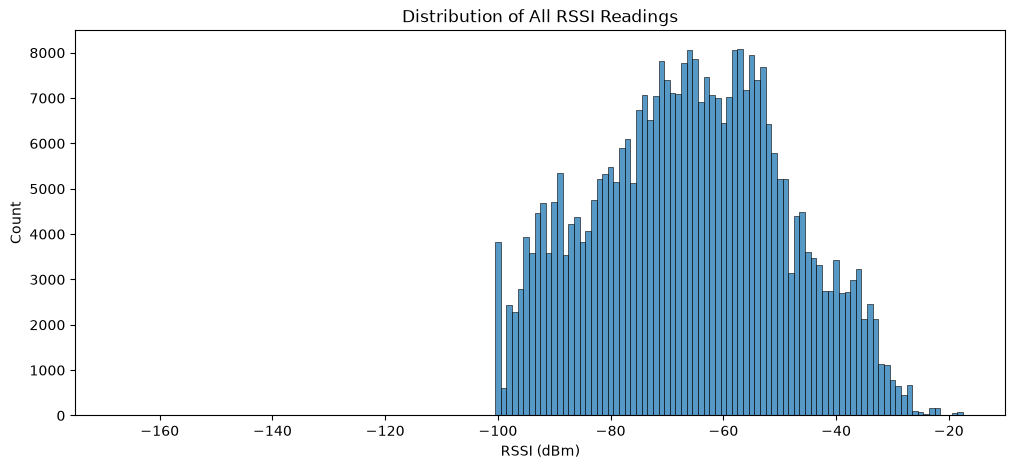

In [82]:
import seaborn as sns
# Melt dataset to plot distribution of all APs together
rssi_cols = [c for c in df.columns if c not in ['X', 'Y']]
df_melted = df[rssi_cols].melt(var_name='AP', value_name='RSSI')

plt.figure(figsize=(12, 5))
sns.histplot(data=df_melted, x='RSSI',binwidth=1, discrete=True)
plt.title("Distribution of All RSSI Readings")
plt.xlabel("RSSI (dBm)")
plt.ylabel("Count")
plt.show()

In this plot we see a histogram of different ranges in RSSI values on the X axis and their frequency in the Y axis. The majority of RSSI measurements seem to be concentrated at around -80 to -50 dBm, which indicates a moderate reception from the accesspoints. At the right tail end of the curve, we see that the strongest signals recede sharply at maximum -20 dBm. The interesting part of this histogram is at the left end of the tail where counts suddenly cuts of at around 100 dBm. This cutoff is related to the wifi chip's hardware limits as it is unable detect or distinguish signals weaker than this threshold. For that reason, we treat 100 dBm as a natural lower bound for our model. 

Another notable feature about this histogram is the possibility of signals that extend beyond -100dBm. Since the curve starts halfway through the X-axis, this may indicate that rare values exist further to the left but they are too sparse to show up visually on the graph. We can print out the lowest RSSI values that was measured on each access point.



In [83]:
print("Minimum RSSI value per AP:")
print(df[rssi_cols].min())

Minimum RSSI value per AP:
84:16:f9:9f:41:d4   -100
b0:c7:45:b3:d0:b8   -100
84:16:f9:9f:40:15   -100
84:16:f9:9f:41:d3    -97
84:16:f9:9f:53:c5   -100
84:16:f9:9f:40:14    -97
84:16:f9:9f:55:ed   -100
b0:c7:45:b3:d0:bc   -100
00:19:5b:06:bf:c2   -100
84:16:f9:9f:53:c4   -100
84:16:f9:9f:55:ec   -167
dtype: int64


In the table above, we see an data anomaly at the last accespoint showing value of -167dBm. There might be many more values below -100 but these values impossible given the hardware that we are working with. These values may have been created artifially by the logging software used when gathering the data or generated in some other unexplainable way. For that reason, we will clip the dataset to our lower bound starting at -100dBm in order remove the unwanted noise from our dataset.

### Checking for null values

In [84]:
print(df.isnull().sum())

X                    0
Y                    0
84:16:f9:9f:41:d4    0
b0:c7:45:b3:d0:b8    0
84:16:f9:9f:40:15    0
84:16:f9:9f:41:d3    0
84:16:f9:9f:53:c5    0
84:16:f9:9f:40:14    0
84:16:f9:9f:55:ed    0
b0:c7:45:b3:d0:bc    0
00:19:5b:06:bf:c2    0
84:16:f9:9f:53:c4    0
84:16:f9:9f:55:ec    0
dtype: int64


Looking at the dataset we see that it contains no missing values.

### Duplicate values

As the robot collects data, duplicate values might appear in the dataset if the bot idles in one location and recorded identical scans at position (X,Y). These duplicates causes problems when splitting the data in train and test sets as an identical copy may appear in both X_train and X_test which results in data leakage.

In [104]:
duplicates = df.duplicated().sum()

print(f"Full-row duplicates: {duplicates}")

Full-row duplicates: 1099


## Preparing the data

### Fixing the lower bound

We begin by clipping the data to our pre-determined lower bound.

In [86]:
lower_bound = -100
df_clipped = df.copy()
df_clipped[rssi_cols] = df_clipped[rssi_cols].clip(lower=-100) # Clipping values lower than -100 dBm to our lower bound.

The curve now starts at -100 dBm.

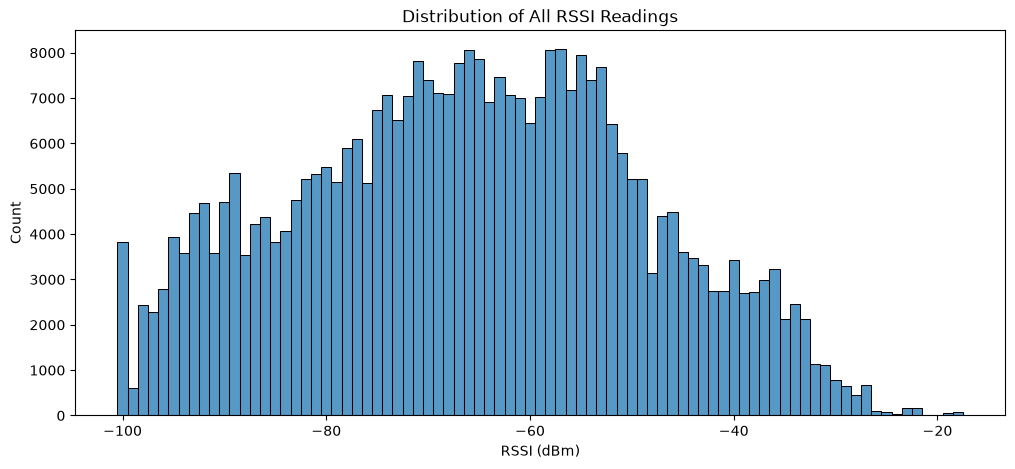

In [87]:
df_clipped_melted = df_clipped[rssi_cols].melt(var_name='AP', value_name='RSSI')

plt.figure(figsize=(12, 5))
sns.histplot(data=df_clipped_melted, x='RSSI', binwidth=1, discrete=True)
plt.title("Distribution of All RSSI Readings")
plt.xlabel("RSSI (dBm)")
plt.ylabel("Count")
plt.show()

### Removing duplicate values

In order to avoid data leakage during data splitting, we will drop all duplicate values.

In [92]:
df_cleaned = df_clipped.copy()
df_cleaned = df_cleaned.drop_duplicates()

print(f"Full-row duplicates: {df_cleaned.duplicated().sum()}")

Full-row duplicates: 0


## Choosing a model

### Evalation metric and cross validation

Before picking a model, we have to pick an evaluation metric to asses the accuracy of the model. Since the target variable is a 2D coordinate, euclidian distance can be used to measure the error between the predicted and true coordinates. 

In order to get a better estimate of the performance on unseen data we will use cross validation on K-folds. A custom implementation will have to made for euclidian distances.

In [99]:
from sklearn.model_selection import KFold
from sklearn.base import clone
import numpy as np

# Custom implementation of cross validation using K-Folds
def cross_validate_coordinates(X:pd.DataFrame, y:pd.DataFrame, model , k_folds:int=5):

    test_scores = []

    skfolds = KFold(n_splits=k_folds,shuffle=True, random_state=42)

    # Split indices
    for train_index, test_index in skfolds.split(X):

        clone_model = clone(model)

        # Split train and test sets using indices
        X_train_folds = X.iloc[train_index]
        y_train_folds = y.iloc[train_index]
        X_test_fold = X.iloc[test_index]
        y_test_fold = y.iloc[test_index]

        # Train model
        clone_model.fit(X_train_folds, y_train_folds)
        y_pred = clone_model.predict(X_test_fold)

        # Euclidian distance error across all test predictions
        diff = y_test_fold.values - y_pred
        euc_distances = np.sqrt(np.sum(diff**2,axis=1))

        mean_euc_dst_error = np.mean(euc_distances) # calculate mean euclidian distance error
        test_scores.append(mean_euc_dst_error) # Add mean to list of errors


    return test_scores  


Before training we have to split our data into train and test set. In order to avoid splitting ordered data, we will use a randomized split using train_test_split.

In [94]:
from sklearn.model_selection import train_test_split

X = df_cleaned[rssi_cols]
y = df_cleaned[['X','Y']]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,shuffle=True,random_state=42)


As a start, we can use a tree based regression model to fit the data.

In [97]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
n_estimators=100,
random_state=42,
n_jobs=-1
)

rf_reg.fit(
X_train,
y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [102]:
cv_errors = cross_validate_coordinates(X_train, y_train, rf_reg, k_folds=5)

print("Validation Error per fold:", cv_errors)
print(f"Mean CV Error: {np.mean(cv_errors):.2f} +- {np.std(cv_errors):.2f} meters")

Validation Error per fold: [np.float64(0.11192456082171132), np.float64(0.10860300837266372), np.float64(0.12539103984621008), np.float64(0.1215664925584466), np.float64(0.10778078356035889)]
Mean CV Error: 0.12 +- 0.01 meters
